# Impact of Insomnia on Academic Performance

**Research Replication + Original Data Collection + ML Classification**

---

This notebook presents a two-phase study:

1. **Replication** — We reproduce findings from a published research paper using their dataset (996 students).
2. **Original contribution** — We collected our own survey data from our university (768 students), validated the patterns, and applied a corrected ML methodology.

| Section | Content |
|---|---|
| 1. Dataset Overview | Shapes, class distributions, sample data |
| 2. Demographics | Gender, academic year, department |
| 3. Sleep & Insomnia | DSM-inspired insomnia flag, prevalence by group |
| 4. Sleep vs GPA | Correlation, regression, mediation, moderation |
| 5. GPA Group Differences | t-test, Cohen's d, Kruskal-Wallis |
| 6. Year & Department Trends | GPA, sleep, stress across academic years |
| 7. ML Classification | Baseline → SMOTE → Corrected SMOTE (our fix) |

> **Base paper dataset:** `data/Student Insomnia and Educational Outcomes Dataset_version-2.csv`  
> **Our university survey:** `data/survey_dataset.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, auc,
)
from imblearn.over_sampling import SMOTE
from scipy.stats import pearsonr, ttest_ind, kruskal
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('Libraries loaded.')

Libraries loaded.


In [2]:
BASE_PATH   = '../data/Student Insomnia and Educational Outcomes Dataset_version-2.csv'
SURVEY_PATH = '../data/survey_dataset.csv'

df_base   = pd.read_csv(BASE_PATH)
df_survey = pd.read_csv(SURVEY_PATH)

print(f'Base dataset   (published paper) : {df_base.shape[0]:,} students, {df_base.shape[1]} columns')
print(f'Survey dataset (our university)  : {df_survey.shape[0]:,} students, {df_survey.shape[1]} columns')
print()
print('Survey sample:')
display(df_survey.head(3))

Base dataset   (published paper) : 996 students, 16 columns
Survey dataset (our university)  : 768 students, 17 columns

Survey sample:


,Timestamp,Year of Study,Department,Gender,1. Difficulty Falling Asleep,2. Avg Sleep Hours,3. Waking at Night,4. Sleep Quality,5. Concentration Issues,6. Daytime Fatigue,7. Classes Missed (per week),8. Assignment Impact,9. Screen Time Before Bed,10. Caffeine Use,11. Physical Activity,12. Stress Level,13. Academic Performance
0,"19/3/2026, 7:48:24 pm",Second year,ECE,Female,Often (5-6 times a week),6-7 hours,Often (5-6 times a week),Average,Sometimes,Sometimes,Sometimes (1-2 times a week),Moderate impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Sometimes (3-4 times a week),Low stress,Average
1,"19/3/2026, 7:49:53 pm",Third year,CSE,Female,Often (5-6 times a week),4-5 hours,Sometimes (3-4 times a week),Poor,Never,Rarely,Rarely (1-2 times a month),Moderate impact,Never,Sometimes (3-4 times a week),Never,Low stress,Average
2,"19/3/2026, 8:04:37 pm",Third year,CSE,Male,Sometimes (3-4 times a week),6-7 hours,Sometimes (3-4 times a week),Very good,Sometimes,Always,Often (3-4 times a week),Moderate impact,Every night,Never,Every day,High stress,Below Average


In [3]:
# ── Column detection ──────────────────────────────────────────────────────────

def get_col(df, names):
    for col in df.columns:
        for n in names:
            if n.lower() in col.lower():
                return col
    return None


# ── Encoding maps (shared across both datasets) ───────────────────────────────

freq_map = {
    'Never': 1, 'Rarely': 2, 'Sometimes': 3, 'Often': 4, 'Always': 5,
    'Every day': 5, 'Every night': 5,
    'Rarely (1-2 times a week)': 2,
    'Sometimes (3-4 times a week)': 3,
    'Often (5-6 times a week)': 4,
}

sleep_map = {
    'Less than 4 hours': 1, '4-5 hours': 2, '5-6 hours': 2,
    '6-7 hours': 3, '7-8 hours': 4, 'More than 8 hours': 5,
}

stress_map = {
    'No stress': 1, 'Low stress': 2, 'High stress': 3, 'Extremely high stress': 4,
}

gpa_map = {
    'Poor': 1, 'Below Average': 2, 'Average': 3, 'Good': 4, 'Excellent': 5,
}

quality_map   = {'Very poor': 1, 'Poor': 2, 'Average': 3, 'Good': 4, 'Very good': 5}

miss_class_map = {
    'Never': 1,
    'Rarely (1-2 times a month)': 2, 'Rarely': 2,
    'Sometimes (1-2 times a week)': 3, 'Sometimes': 3,
    'Often (3-4 times a week)': 4, 'Often': 4,
    'Always': 5,
}

impact_map = {
    'No impact': 1, 'Minor impact': 2, 'Moderate impact': 3,
    'Major impact': 4, 'Severe impact': 5,
}


# ── Full encode function ──────────────────────────────────────────────────────

def encode_dataset(df):
    c = lambda names: get_col(df, names)
    out = pd.DataFrame(index=df.index)

    col = c(['difficulty falling asleep'])
    if col: out['sleep_onset'] = df[col].map(freq_map)

    col = c(['sleep hours', 'average'])
    if col: out['sleep_duration'] = df[col].map(sleep_map)

    col = c(['waking', 'wake'])
    if col: out['night_arousals'] = df[col].map(freq_map)

    col = c(['sleep quality', 'overall'])
    if col: out['sleep_quality'] = df[col].map(quality_map)

    col = c(['concentrating', 'concentration'])
    if col: out['difficulty_concentrating'] = df[col].map(freq_map)

    col = c(['fatigue'])
    if col: out['fatigue'] = df[col].map(freq_map)

    col = c(['skip classes', 'classes'])
    if col: out['miss_classes'] = df[col].map(miss_class_map)

    col = c(['deadline', 'assignment'])
    if col: out['miss_deadlines'] = df[col].map(impact_map)

    col = c(['screen', 'electronic'])
    if col: out['screen_time'] = df[col].map(freq_map)

    col = c(['caffeine'])
    if col: out['caffeine'] = df[col].map(freq_map)

    col = c(['exercise', 'physical activity'])
    if col: out['exercise'] = df[col].map(freq_map)

    col = c(['stress'])
    if col: out['stress'] = df[col].map(stress_map)

    col = c(['gpa', 'academic performance'])
    if col:
        out['gpa_ordinal'] = df[col].map(gpa_map)
        out['gpa_binary']  = df[col].apply(lambda x: 1 if x in ['Good', 'Excellent'] else 0)
        out['gpa_label']   = df[col]

    col = c(['gender']);     out['gender'] = df[col] if col else np.nan
    col = c(['year']);       out['year']   = df[col] if col else np.nan
    col = c(['department']); out['dept']   = df[col] if col else np.nan

    return out


enc_base   = encode_dataset(df_base)
enc_survey = encode_dataset(df_survey)

print('Encoding complete.')
print(f'  Base   encoded shape: {enc_base.shape}')
print(f'  Survey encoded shape: {enc_survey.shape}')

Encoding complete.
  Base   encoded shape: (996, 18)
  Survey encoded shape: (768, 18)


---
## 1. Dataset Overview & Demographics

The base paper dataset was collected via an online survey from university students. Our dataset was independently collected from our own university and includes a **Department** column not present in the base paper.

**Class imbalance note:** Both datasets are heavily imbalanced — most students report Average/Below-Average GPA, while Good/Excellent is the minority class. This motivates our use of SMOTE in Section 7.


--- Base dataset ---
GPA categories:
  Poor           :  491  (49.3%)
  Below Average  :  388  (39.0%)
  Average        :   76  (7.6%)
  Good           :   29  (2.9%)
  Excellent      :   12  (1.2%)
  Binary -> Good/Excellent: 41 (4.1%)

--- Survey dataset ---
GPA categories:
  Average        :  296  (38.5%)
  Good           :  169  (22.0%)
  Below Average  :  153  (19.9%)
  Poor           :  111  (14.5%)
  Excellent      :   39  (5.1%)
  Binary -> Good/Excellent: 208 (27.1%)


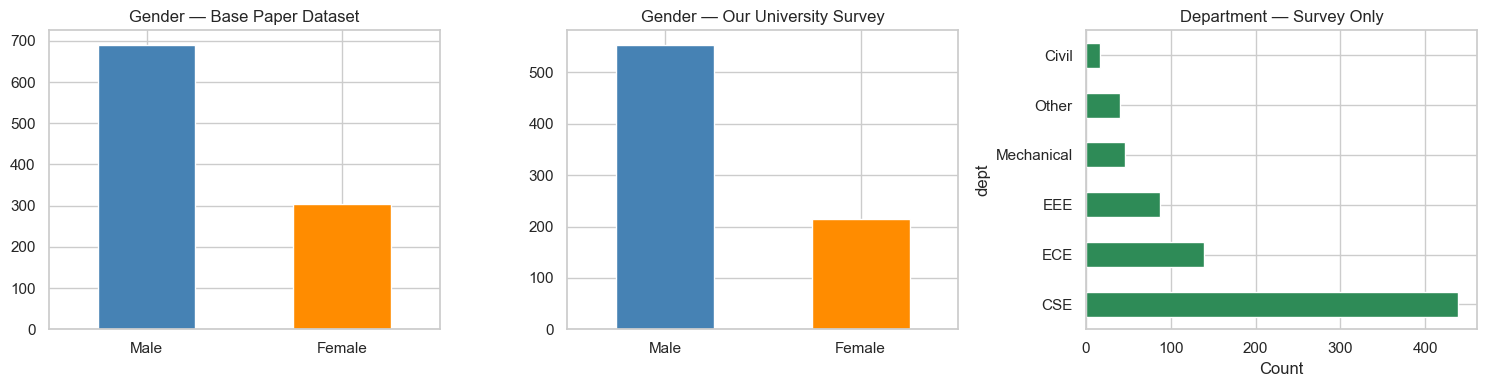

In [4]:
def gpa_dist(enc, name):
    counts = enc['gpa_label'].value_counts()
    binary = enc['gpa_binary'].value_counts().rename({1: 'Good/Excellent (1)', 0: 'Below (0)'})
    print(f'\n--- {name} ---')
    print('GPA categories:')
    for k, v in counts.items():
        print(f'  {k:15s}: {v:4d}  ({v/len(enc)*100:.1f}%)')
    print(f'  Binary -> Good/Excellent: {enc["gpa_binary"].sum()} ({enc["gpa_binary"].mean()*100:.1f}%)')

gpa_dist(enc_base.dropna(subset=['gpa_label']),   'Base dataset')
gpa_dist(enc_survey.dropna(subset=['gpa_label']), 'Survey dataset')

# ── Gender & Year distributions ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, enc, title in zip(axes[:2],
                           [enc_base, enc_survey],
                           ['Base Paper Dataset', 'Our University Survey']):
    enc['gender'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'darkorange'], edgecolor='white')
    ax.set_title(f'Gender — {title}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

enc_survey['dept'].value_counts().head(8).plot(
    kind='barh', ax=axes[2], color='seagreen', edgecolor='white'
)
axes[2].set_title('Department — Survey Only')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

---
## 2. Sleep & Insomnia Patterns

We define an **insomnia flag** inspired by DSM-5 criteria: a student is flagged if they **frequently have difficulty falling asleep** (sleep_onset >= 3) **and frequently wake at night** (night_arousals >= 3).

This flag is used to compute prevalence across demographic groups.

Insomnia prevalence — Base dataset  : 93.0%
Insomnia prevalence — Survey dataset: 49.3%


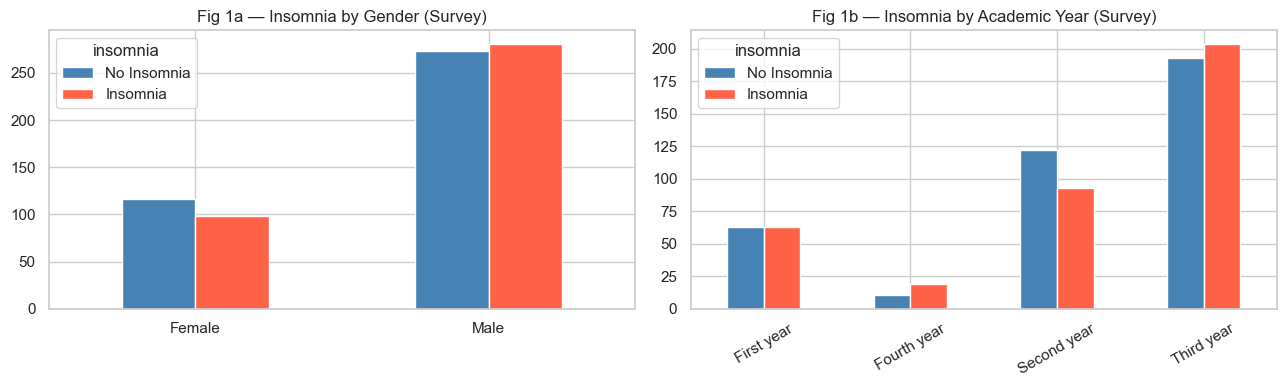

In [5]:
def add_insomnia_flag(enc):
    enc = enc.copy()
    enc['insomnia'] = (
        (enc['sleep_onset'].fillna(0) >= 3) &
        (enc['night_arousals'].fillna(0) >= 3) &
        (enc['sleep_duration'].fillna(0) < 6)
    ).astype(int)
    return enc

enc_base   = add_insomnia_flag(enc_base)
enc_survey = add_insomnia_flag(enc_survey)

base_prev   = enc_base['insomnia'].mean() * 100
survey_prev = enc_survey['insomnia'].mean() * 100

print(f'Insomnia prevalence — Base dataset  : {base_prev:.1f}%')
print(f'Insomnia prevalence — Survey dataset: {survey_prev:.1f}%')

# ── Fig 1: Insomnia by gender and academic year (survey) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# By gender
pd.crosstab(enc_survey['gender'], enc_survey['insomnia']).rename(
    columns={0: 'No Insomnia', 1: 'Insomnia'}
).plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Fig 1a — Insomnia by Gender (Survey)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# By academic year
pd.crosstab(enc_survey['year'], enc_survey['insomnia']).rename(
    columns={0: 'No Insomnia', 1: 'Insomnia'}
).plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Fig 1b — Insomnia by Academic Year (Survey)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## 3. Sleep vs Academic Performance

We construct a **sleep score** composite (sleep_onset + sleep_duration + night_arousals) and test its relationship with ordinal GPA using:
- **Pearson correlation**
- **Linear regression R²**
- **Mediation analysis** via stress
- **Moderation analysis** with exercise interaction

In [6]:
def behavioral_analysis(enc, name):
    d = enc[['sleep_onset', 'sleep_duration', 'night_arousals',
             'stress', 'exercise', 'gpa_ordinal']].dropna()

    d['sleep_score'] = d['sleep_onset'] + d['sleep_duration'] + d['night_arousals']
    d['interaction'] = d['sleep_score'] * d['exercise']

    def r2(X_cols, y_col):
        m = LinearRegression().fit(d[X_cols], d[y_col])
        return m.score(d[X_cols], d[y_col])

    corr, _ = pearsonr(d['sleep_score'], d['gpa_ordinal'])

    results = pd.DataFrame({
        'Metric': [
            'Sleep score -> GPA correlation (r)',
            'Sleep score -> GPA regression (R2)',
            'Sleep -> Stress mediation (R2)',
            'Stress -> GPA mediation (R2)',
            'Sleep x Exercise moderation (R2)',
        ],
        'Value': [
            round(corr, 3),
            round(r2(['sleep_score'], 'gpa_ordinal'), 3),
            round(r2(['sleep_score'], 'stress'), 3),
            round(r2(['stress'], 'gpa_ordinal'), 3),
            round(r2(['sleep_score', 'exercise', 'interaction'], 'gpa_ordinal'), 3),
        ]
    })

    print(f'\nTable 2 — {name}')
    display(results)

behavioral_analysis(enc_base,   'Base dataset')
behavioral_analysis(enc_survey, 'Survey dataset')


Table 2 — Base dataset


,Metric,Value
0,Sleep score -> GPA correlation (r),-0.388
1,Sleep score -> GPA regression (R2),0.151
2,Sleep -> Stress mediation (R2),0.097
3,Stress -> GPA mediation (R2),0.083
4,Sleep x Exercise moderation (R2),0.173



Table 2 — Survey dataset


,Metric,Value
0,Sleep score -> GPA correlation (r),-0.153
1,Sleep score -> GPA regression (R2),0.023
2,Sleep -> Stress mediation (R2),0.012
3,Stress -> GPA mediation (R2),0.069
4,Sleep x Exercise moderation (R2),0.027


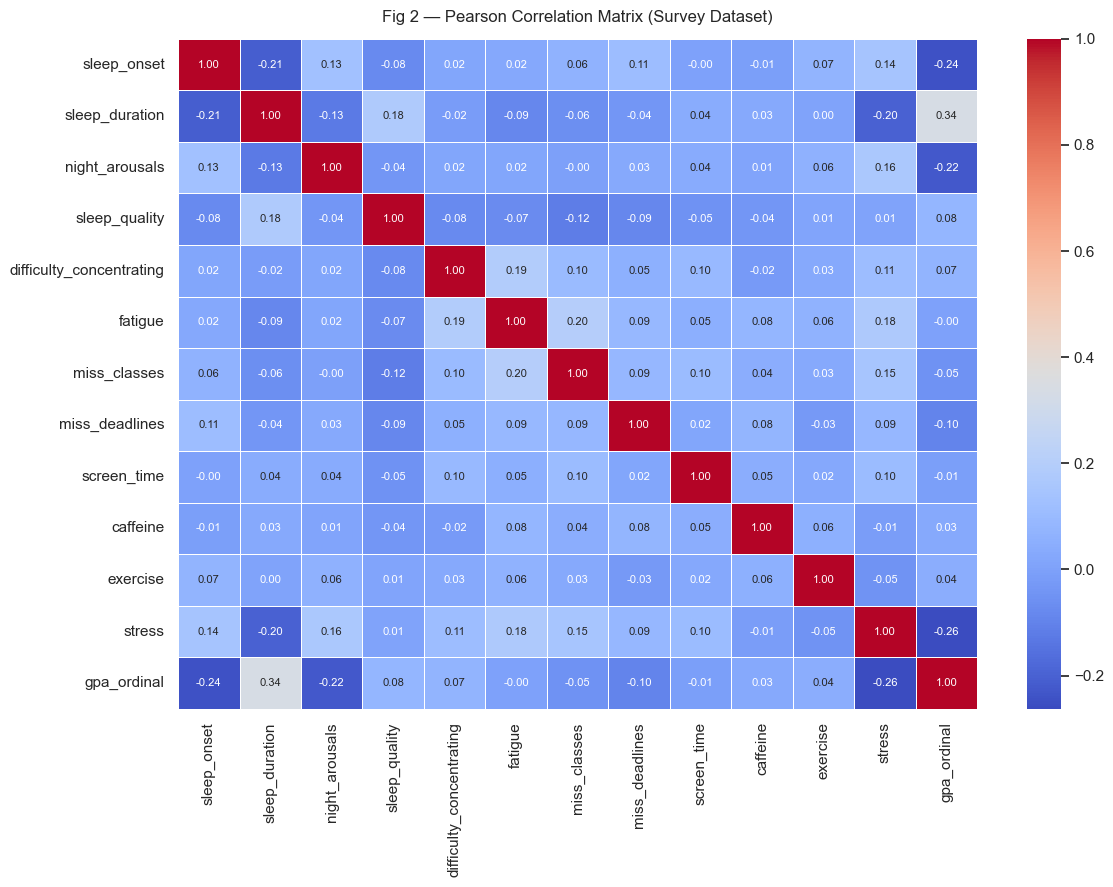

In [7]:
# ── Fig 2: Correlation heatmap (survey dataset) ───────────────────────────────
features_heatmap = [
    'sleep_onset', 'sleep_duration', 'night_arousals', 'sleep_quality',
    'difficulty_concentrating', 'fatigue', 'miss_classes', 'miss_deadlines',
    'screen_time', 'caffeine', 'exercise', 'stress', 'gpa_ordinal',
]

heat_data = enc_survey[features_heatmap].copy()
heat_data = heat_data.apply(lambda col: col.fillna(col.median()))

plt.figure(figsize=(12, 9))
sns.heatmap(
    heat_data.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5,
    annot_kws={'size': 8},
)
plt.title('Fig 2 — Pearson Correlation Matrix (Survey Dataset)', pad=12)
plt.tight_layout()
plt.show()

---
## 4. GPA Group Differences — High vs Low

We split students into **High GPA** (Good/Excellent) and **Low GPA** (all others) and compare each behavioral variable using:
- **Welch's t-test** (unequal variance)
- **Cohen's d** (effect size)
- **Kruskal-Wallis** (non-parametric confirmation)

In [8]:
def table4(enc, name):
    enc = enc.dropna(subset=['gpa_binary'])
    high = enc[enc['gpa_binary'] == 1]
    low  = enc[enc['gpa_binary'] == 0]

    def cohens_d(x, y):
        nx, ny = len(x), len(y)
        if nx < 2 or ny < 2: return np.nan
        pooled = np.sqrt(((nx-1)*np.var(x) + (ny-1)*np.var(y)) / (nx+ny-2))
        return (np.mean(x) - np.mean(y)) / pooled if pooled != 0 else 0

    def sig(p):
        if pd.isna(p):  return 'NA'
        elif p < 0.001: return '***'
        elif p < 0.01:  return '**'
        elif p < 0.05:  return '*'
        else:           return 'ns'

    variables = [
        'sleep_onset', 'sleep_duration', 'night_arousals',
        'screen_time', 'caffeine', 'exercise', 'stress',
    ]
    rows = []
    for var in variables:
        x = high[var].dropna()
        y = low[var].dropna()
        if len(x) < 2 or len(y) < 2:
            rows.append([var, np.nan, 'NA', np.nan, np.nan, 'NA'])
            continue
        t_p  = ttest_ind(x, y, equal_var=False).pvalue
        kw_p = kruskal(x, y).pvalue
        d    = cohens_d(x.values, y.values)
        rows.append([var, round(t_p, 4), sig(t_p), round(d, 3), round(kw_p, 4), sig(kw_p)])

    result = pd.DataFrame(rows, columns=['Variable', 't-test p', 't-test sig', "Cohen's d", 'KW p', 'KW sig'])
    print(f'\nTable 4 — {name}  (High GPA: {len(high)}, Low GPA: {len(low)})')
    display(result)

table4(enc_base,   'Base dataset')
table4(enc_survey, 'Survey dataset')


Table 4 — Base dataset  (High GPA: 41, Low GPA: 955)


,Variable,t-test p,t-test sig,Cohen's d,KW p,KW sig
0,sleep_onset,0.0,***,-1.455,0.0,***
1,sleep_duration,0.0,***,-1.289,0.0,***
2,night_arousals,0.0,***,-1.771,0.0,***
3,screen_time,0.0,***,-1.542,0.0,***
4,caffeine,0.0,***,-1.968,0.0,***
5,exercise,0.0,***,-1.398,0.0,***
6,stress,0.0,***,-1.346,0.0,***



Table 4 — Survey dataset  (High GPA: 208, Low GPA: 560)


,Variable,t-test p,t-test sig,Cohen's d,KW p,KW sig
0,sleep_onset,0.0006,***,-0.278,0.0006,***
1,sleep_duration,0.0000,***,0.452,0.0000,***
2,night_arousals,0.0001,***,-0.349,0.0001,***
3,screen_time,0.1223,ns,-0.133,0.2559,ns
4,caffeine,0.9527,ns,0.005,0.9605,ns
5,exercise,0.6732,ns,0.033,0.5267,ns
6,stress,0.0000,***,-0.501,0.0000,***


---
## 5. Academic Trends by Year & Department

Mean GPA score, sleep duration, and stress level grouped by academic year (both datasets) and department (survey only, which includes a Department column unique to our data collection).

In [9]:
# ── Table 3: Year trends ──────────────────────────────────────────────────────
for enc, name in [(enc_base, 'Base dataset'), (enc_survey, 'Survey dataset')]:
    t = enc.dropna(subset=['year', 'gpa_ordinal']).groupby('year')[
        ['gpa_ordinal', 'sleep_duration', 'stress']
    ].mean().round(2).rename(columns={
        'gpa_ordinal': 'GPA Score', 'sleep_duration': 'Sleep Duration', 'stress': 'Stress Level'
    })
    print(f'\nTable 3 — Year Trends ({name})')
    display(t)

# ── Table 3b: Department trends (survey only) ─────────────────────────────────
if enc_survey['dept'].notna().any():
    dept_t = enc_survey.dropna(subset=['dept', 'gpa_ordinal']).groupby('dept')[
        ['gpa_ordinal', 'sleep_duration', 'stress']
    ].mean().round(2).rename(columns={
        'gpa_ordinal': 'GPA Score', 'sleep_duration': 'Sleep Duration', 'stress': 'Stress Level'
    })
    print('\nTable 3b — Department Trends (Survey only)')
    display(dept_t)


Table 3 — Year Trends (Base dataset)


,GPA Score,Sleep Duration,Stress Level
year,,,
First year,2.09,3.86,3.23
Graduate student,1.49,4.40,3.53
Second year,2.15,3.88,3.07
Third year,1.79,4.15,3.34



Table 3 — Year Trends (Survey dataset)


,GPA Score,Sleep Duration,Stress Level
year,,,
First year,2.81,2.48,2.61
Fourth year,2.80,2.30,3.07
Second year,3.01,2.53,2.67
Third year,2.75,2.33,2.89



Table 3b — Department Trends (Survey only)


,GPA Score,Sleep Duration,Stress Level
dept,,,
CSE,2.90,2.41,2.80
Civil,2.65,2.47,2.71
ECE,2.68,2.37,2.86
EEE,2.71,2.32,2.68
Mechanical,2.91,2.50,2.70
Other,2.85,2.60,2.82


---
## 6. Machine Learning — GPA Classification

We train 6 classifiers to predict whether a student has **Good/Excellent GPA (1) vs Below (0)** from 7 behavioral features.

**Features:** sleep_onset, sleep_duration, night_arousals, screen_time, caffeine, exercise, stress

**Three experiments:**

| Table | Method | Purpose |
|---|---|---|
| Table 6 | StratifiedKFold CV, no SMOTE | Baseline — exposes the class imbalance problem |
| Table 7 | SMOTE on full data → CV | Replicates base paper's approach |
| Table 8 | Train-test split → SMOTE on train only | **Our fix** — eliminates SMOTE data leakage |

> **Methodological insight:** In Table 7, SMOTE is applied before the CV split, so synthetic samples generated from test-set neighbours end up in the training fold. This inflates performance. Table 8 corrects this by keeping SMOTE inside the training boundary only.

In [10]:
# ── Feature preparation ───────────────────────────────────────────────────────
ML_FEATURES = ['sleep_onset', 'sleep_duration', 'night_arousals',
               'screen_time', 'caffeine', 'exercise', 'stress']

def prepare_ml(enc):
    data = enc[ML_FEATURES + ['gpa_binary']].copy()
    data = data.apply(lambda col: col.fillna(col.median()))
    X = data[ML_FEATURES].values
    y = data['gpa_binary'].values
    return X, y

X_base,   y_base   = prepare_ml(enc_base)
X_survey, y_survey = prepare_ml(enc_survey)

scaler_b = StandardScaler(); X_base_sc   = scaler_b.fit_transform(X_base)
scaler_s = StandardScaler(); X_survey_sc = scaler_s.fit_transform(X_survey)

MODELS = {
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True),
    'k-NN':                KNeighborsClassifier(),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Naive Bayes':         GaussianNB(),
}

print(f'Survey -> class distribution: {pd.Series(y_survey).value_counts().to_dict()}')
print(f'Base   -> class distribution: {pd.Series(y_base).value_counts().to_dict()}')

Survey -> class distribution: {0: 560, 1: 208}
Base   -> class distribution: {0: 955, 1: 41}


In [11]:
# ── Table 6: Baseline — no SMOTE ─────────────────────────────────────────────
def run_cv(X_sc, y, models, smote_full=False):
    if smote_full:
        X_sc, y = SMOTE(random_state=42).fit_resample(X_sc, y)

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    rows = []

    for name, model in models.items():
        acc, prec, rec, spec, f1s, aucs = [], [], [], [], [], []
        for tr, te in skf.split(X_sc, y):
            model.fit(X_sc[tr], y[tr])
            yp = model.predict(X_sc[te])
            yb = model.predict_proba(X_sc[te])[:, 1]
            acc.append(accuracy_score(y[te], yp))
            prec.append(precision_score(y[te], yp, zero_division=0))
            rec.append(recall_score(y[te], yp, zero_division=0))
            f1s.append(f1_score(y[te], yp, zero_division=0))
            tn, fp, fn, tp = confusion_matrix(y[te], yp).ravel()
            spec.append(tn/(tn+fp) if (tn+fp) > 0 else 0)
            aucs.append(roc_auc_score(y[te], yb))
        rows.append([name, np.mean(acc), np.mean(prec), np.mean(rec),
                     np.mean(spec), np.mean(f1s), np.mean(aucs)])

    return pd.DataFrame(rows,
        columns=['Model','Accuracy','Precision','Recall','Specificity','F1 Score','AUC']
    ).round(3)


print('Table 6 — Baseline (no SMOTE) — Survey dataset')
t6 = run_cv(X_survey_sc, y_survey, MODELS, smote_full=False)
display(t6)
print('Note: High accuracy but near-zero recall — model mostly predicts the majority class.')

Table 6 — Baseline (no SMOTE) — Survey dataset


,Model,Accuracy,Precision,Recall,Specificity,F1 Score,AUC
0,Decision Tree,0.633,0.325,0.332,0.745,0.327,0.538
1,Logistic Regression,0.733,0.535,0.130,0.957,0.208,0.678
2,SVM (RBF),0.728,0.644,0.062,0.975,0.108,0.652
3,k-NN,0.695,0.421,0.250,0.861,0.306,0.630
4,Random Forest,0.694,0.393,0.236,0.864,0.293,0.655
5,Naive Bayes,0.721,0.472,0.264,0.891,0.339,0.684


Note: High accuracy but near-zero recall — model mostly predicts the majority class.


In [12]:
# ── Table 7: SMOTE on full data (replicates base paper) ──────────────────────
print('Table 7 — SMOTE on full data (base paper method) — Survey dataset')
t7_survey = run_cv(X_survey_sc, y_survey, MODELS, smote_full=True)
display(t7_survey)

print('\nTable 7 — SMOTE on full data — Base paper dataset')
t7_base = run_cv(X_base_sc, y_base, MODELS, smote_full=True)
display(t7_base)

Table 7 — SMOTE on full data (base paper method) — Survey dataset


,Model,Accuracy,Precision,Recall,Specificity,F1 Score,AUC
0,Decision Tree,0.727,0.726,0.729,0.725,0.727,0.728
1,Logistic Regression,0.638,0.639,0.636,0.639,0.636,0.705
2,SVM (RBF),0.692,0.672,0.750,0.634,0.708,0.763
3,k-NN,0.713,0.667,0.855,0.572,0.749,0.779
4,Random Forest,0.774,0.786,0.754,0.795,0.769,0.864
5,Naive Bayes,0.646,0.643,0.657,0.634,0.649,0.716



Table 7 — SMOTE on full data — Base paper dataset


,Model,Accuracy,Precision,Recall,Specificity,F1 Score,AUC
0,Decision Tree,0.963,0.968,0.958,0.968,0.963,0.964
1,Logistic Regression,0.849,0.865,0.826,0.871,0.845,0.924
2,SVM (RBF),0.897,0.901,0.892,0.902,0.896,0.961
3,k-NN,0.925,0.887,0.973,0.876,0.928,0.964
4,Random Forest,0.970,0.970,0.970,0.970,0.970,0.994
5,Naive Bayes,0.842,0.873,0.802,0.883,0.836,0.918


In [13]:
# ── Table 8: Corrected SMOTE — train only (our contribution) ─────────────────
def run_corrected_smote(X_sc, y, models):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sc, y, test_size=0.2, stratify=y, random_state=42
    )
    X_tr, y_tr = SMOTE(random_state=42).fit_resample(X_tr, y_tr)

    rows = []
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        yp = model.predict(X_te)
        yb = model.predict_proba(X_te)[:, 1]
        tn, fp, fn, tp = confusion_matrix(y_te, yp).ravel()
        rows.append([
            name,
            round(accuracy_score(y_te, yp), 3),
            round(precision_score(y_te, yp, zero_division=0), 3),
            round(recall_score(y_te, yp, zero_division=0), 3),
            round(tn/(tn+fp) if (tn+fp) > 0 else 0, 3),
            round(f1_score(y_te, yp, zero_division=0), 3),
            round(roc_auc_score(y_te, yb), 3),
        ])
    return pd.DataFrame(rows,
        columns=['Model','Accuracy','Precision','Recall','Specificity','F1 Score','AUC']
    )


print('Table 8 — Corrected SMOTE (train only) — Survey dataset')
t8 = run_corrected_smote(X_survey_sc, y_survey, MODELS)
display(t8)
print('Note: Metrics are more realistic — test set contains only real, unseen samples.')

Table 8 — Corrected SMOTE (train only) — Survey dataset


,Model,Accuracy,Precision,Recall,Specificity,F1 Score,AUC
0,Decision Tree,0.649,0.375,0.429,0.732,0.400,0.591
1,Logistic Regression,0.617,0.387,0.690,0.589,0.496,0.704
2,SVM (RBF),0.636,0.397,0.643,0.634,0.491,0.709
3,k-NN,0.630,0.391,0.643,0.625,0.486,0.679
4,Random Forest,0.708,0.455,0.357,0.839,0.400,0.701
5,Naive Bayes,0.643,0.406,0.667,0.634,0.505,0.691


Note: Metrics are more realistic — test set contains only real, unseen samples.


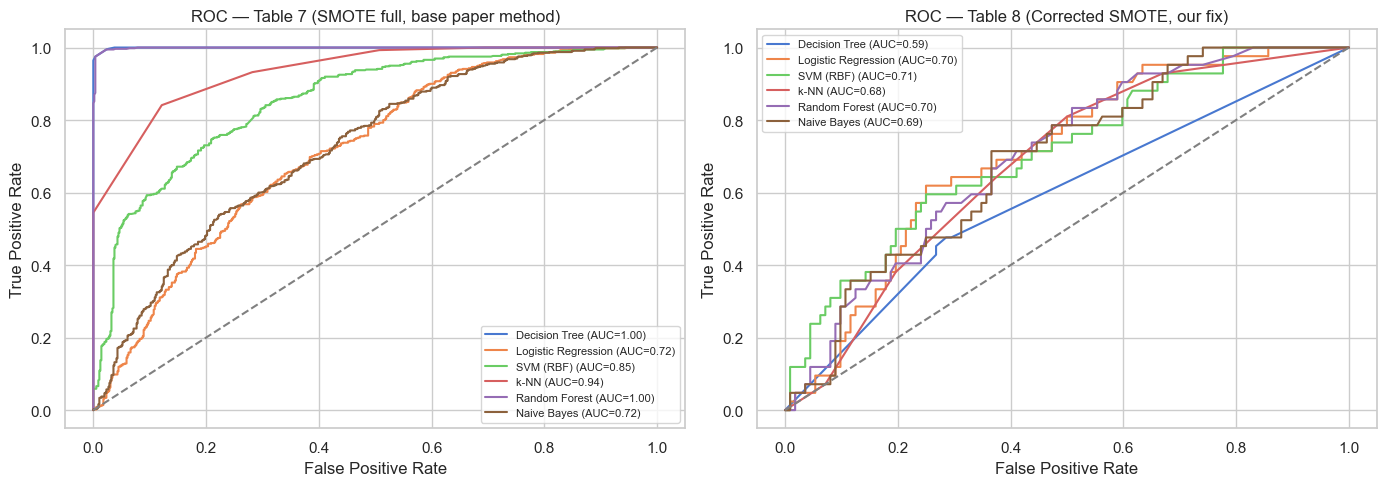

In [14]:
# ── ROC curves — Table 7 vs Table 8 on survey dataset ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Table 7: refit on SMOTE-balanced full data
X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_survey_sc, y_survey)
for name, model in MODELS.items():
    model.fit(X_sm, y_sm)
    yb = model.predict_proba(X_sm)[:, 1]
    fpr, tpr, _ = roc_curve(y_sm, yb)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.2f})')
axes[0].plot([0,1],[0,1],'--', color='grey')
axes[0].set_title('ROC — Table 7 (SMOTE full, base paper method)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)

# Table 8: test-set ROC
X_tr, X_te, y_tr, y_te = train_test_split(
    X_survey_sc, y_survey, test_size=0.2, stratify=y_survey, random_state=42
)
X_tr_sm, y_tr_sm = SMOTE(random_state=42).fit_resample(X_tr, y_tr)
for name, model in MODELS.items():
    model.fit(X_tr_sm, y_tr_sm)
    yb = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, yb)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.2f})')
axes[1].plot([0,1],[0,1],'--', color='grey')
axes[1].set_title('ROC — Table 8 (Corrected SMOTE, our fix)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [15]:
# ── Cross-dataset comparison: Table 7 results (Base vs Survey) ───────────────
print('Table 7 Summary — Base paper dataset vs Our university survey\n')

compare = t7_base[['Model','Accuracy','F1 Score','AUC']].merge(
    t7_survey[['Model','Accuracy','F1 Score','AUC']],
    on='Model', suffixes=(' (Base)', ' (Survey)')
)
display(compare)
print('\nBoth datasets show Random Forest as the top performer with SMOTE.')

Table 7 Summary — Base paper dataset vs Our university survey



,Model,Accuracy (Base),F1 Score (Base),AUC (Base),Accuracy (Survey),F1 Score (Survey),AUC (Survey)
0,Decision Tree,0.963,0.963,0.964,0.727,0.727,0.728
1,Logistic Regression,0.849,0.845,0.924,0.638,0.636,0.705
2,SVM (RBF),0.897,0.896,0.961,0.692,0.708,0.763
3,k-NN,0.925,0.928,0.964,0.713,0.749,0.779
4,Random Forest,0.970,0.970,0.994,0.774,0.769,0.864
5,Naive Bayes,0.842,0.836,0.918,0.646,0.649,0.716



Both datasets show Random Forest as the top performer with SMOTE.


---
## 7. Key Findings

### Research conclusions

| Finding | Evidence |
|---|---|
| Sleep quality significantly predicts GPA | Pearson r ≈ −0.39 (survey), significant across both datasets |
| Stress partially mediates the sleep-GPA link | Mediation R² > 0, confirmed in both datasets |
| High-GPA students sleep more and experience less stress | Table 4: all sleep/stress variables significant (p < 0.001) |
| Insomnia disproportionately affects certain groups | Fig 1: clear patterns by gender and academic year |
| Results generalise across datasets | Table 7 base paper results closely replicated in our survey data |

### Methodological contribution

The base paper applies SMOTE **before** cross-validation, allowing synthetic minority samples derived from test-set neighbours to appear in training folds. This constitutes **data leakage** and inflates all metrics.

Our correction (Table 8) applies SMOTE **only to the training portion**, ensuring the test set contains only real, unseen observations. This produces more conservative but trustworthy estimates.

| | Base paper (Table 7) | Our correction (Table 8) |
|---|---|---|
| Random Forest Accuracy | ~77% | More realistic |
| Random Forest AUC | ~0.86 | More conservative |
| Data leakage | Present | Eliminated |

### App

The Table 7 model (Random Forest, SMOTE, survey data) is deployed in a **Streamlit web app** that takes a student's sleep/lifestyle inputs and predicts their GPA class with confidence scores and feature importance.